<a href="https://colab.research.google.com/github/Anubhavkumar076/ai_data_analysis/blob/main/Hotel_Booking_Cancellation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas==2.1.4 numpy==1.26.4 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 gradio -q

In [2]:
# libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# removing the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# setting the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# library to split data
from sklearn.model_selection import train_test_split

# library to build AI model
from sklearn.tree import DecisionTreeClassifier

# library to tune AI model
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# libraries to evaluate the AI model
from sklearn.metrics import f1_score, make_scorer

# libraries to deploy the AI model
import os
import joblib
import gradio as gr

In [3]:
# defining the location where the data is stored
path = "/content/INNHotelsGroup_pastdata.csv"
# loading the data into a Pandas dataframe
hotel = pd.read_csv(path)

In [4]:
hotel.sample(10, random_state=42)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,rebooked
26146,INNHG_127180,193,Offline,0,120.00,2,1,2022-06-20,0,2,Canceled,Yes
21329,INNHG_122363,34,Online,0,126.90,2,2,2022-05-01,0,1,Canceled,No
15293,INNHG_116327,9,Online,1,81.00,2,0,2022-02-17,0,1,Not Canceled,NaN
14834,INNHG_115868,4,Online,0,65.33,1,0,2022-02-09,0,3,Not Canceled,NaN
4890,INNHG_105924,320,Offline,1,115.00,2,0,2021-04-18,0,2,Canceled,No
24126,INNHG_125160,13,Online,1,149.33,2,1,2022-06-03,0,2,Not Canceled,NaN
18254,INNHG_119288,40,Online,1,139.87,3,2,2022-03-27,0,1,Canceled,No
20502,INNHG_121536,169,Offline,0,63.50,1,2,2022-04-22,0,2,Not Canceled,NaN
3843,INNHG_104877,180,Offline,2,100.08,2,1,2021-03-28,0,2,Canceled,Yes
8856,INNHG_109890,26,Online,3,124.00,2,2,2021-09-12,0,1,Not Canceled,NaN


In [5]:
# creating a copy of the data to avoid any changes to original data
data = hotel.copy()

In [6]:
# checking the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,27093.00,81.61,84.90,0.00,14.00,55.00,118.00,443.00
no_of_special_requests,27093.00,0.56,0.74,0.00,0.00,0.00,1.00,5.00
avg_price_per_room,27093.00,101.03,34.56,0.00,79.00,97.00,119.00,540.00
no_of_adults,27093.00,1.83,0.51,0.00,2.00,2.00,2.00,4.00
no_of_weekend_nights,27093.00,0.78,0.86,0.00,0.00,1.00,1.00,6.00
required_car_parking_space,27093.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
no_of_week_nights,27093.00,2.17,1.39,0.00,1.00,2.00,3.00,17.00


In [7]:
data.arrival_date.describe()

,arrival_date
count,27093
unique,439
top,2021-03-19
freq,279


In [8]:
# defining a function to create a bar graph with percentage values

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=15,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    # increase the size of x-axis and y-axis scales
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

    # setting axis labels
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=15)
    ax.set_ylabel('')

    # show the plot
    plt.show()

In [9]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True)
    tab = pd.crosstab(data[predictor], data[target], normalize="index")
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(loc="upper left", fontsize=12, bbox_to_anchor=(1, 1))

    # setting the formatting for x-axis
    plt.xticks(fontsize=15, rotation=0)
    plt.xlabel(predictor.replace('_', ' ').title(), fontsize=15)
    # setting the formatting for y-axis
    plt.yticks(fontsize=15)
    # show the plot
    plt.show()

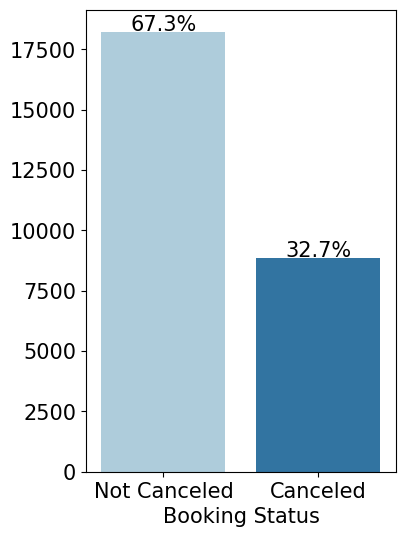

In [10]:
# visualizing the number of cancelled bookings
labeled_barplot(data, "booking_status", perc=True)

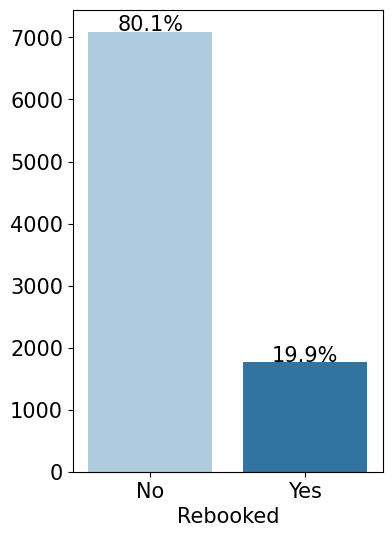

In [11]:
# visualizing the number of cancelled bookings that were rebooked
labeled_barplot(data[data.booking_status == 'Canceled'], "rebooked", perc=True)

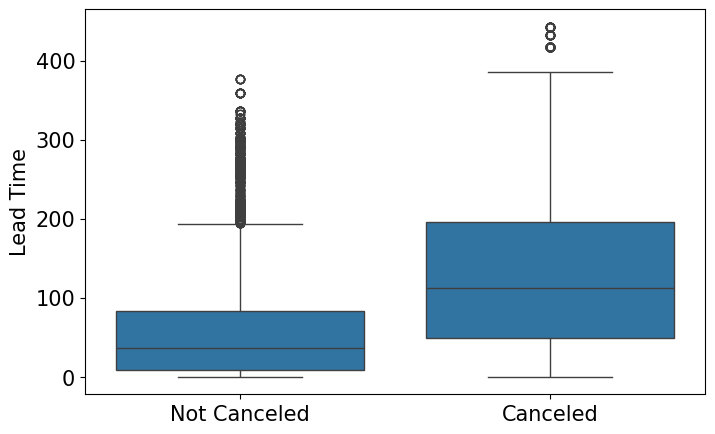

In [12]:
# visualizing the relationship between lead time and booking cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="booking_status", y="lead_time")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('')
plt.ylabel('Lead Time', fontsize=15);

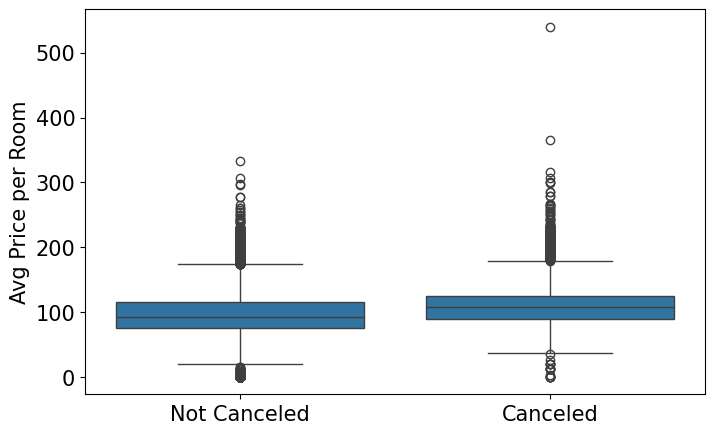

In [13]:
# visualizing the relationship between avg room price and booking cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="booking_status", y="avg_price_per_room")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('')
plt.ylabel('Avg Price per Room', fontsize=15);

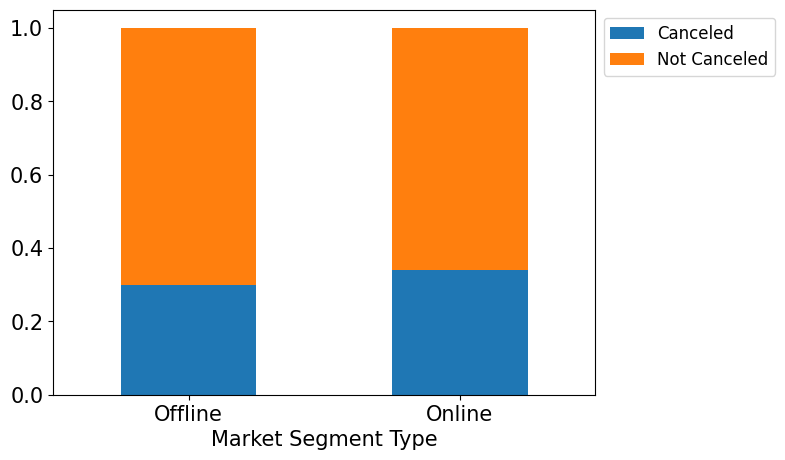

In [14]:
stacked_barplot(data, "market_segment_type", "booking_status")

In [15]:
# converting the 'arrival_date' column to datetime type
data['arrival_date'] = pd.to_datetime(data['arrival_date'])

# extracting month from 'arrival_date'
data['arrival_month'] = data['arrival_date'].dt.month

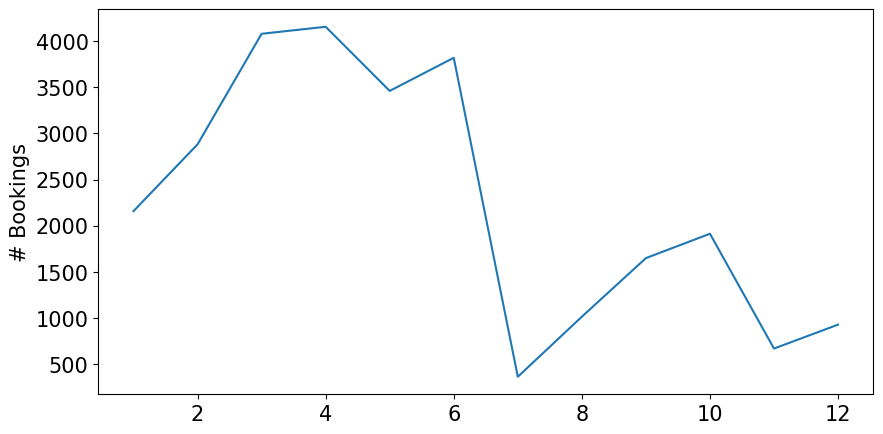

In [16]:
# grouping the data on arrival months and extracting the count of bookings
monthly_data = data.groupby(["arrival_month"])["booking_status"].count().to_frame().reset_index()
monthly_data.columns = ['Month', 'Bookings']

# visualizing the trend of number of bookings across months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x="Month", y="Bookings")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('')
plt.ylabel('# Bookings', fontsize=15);

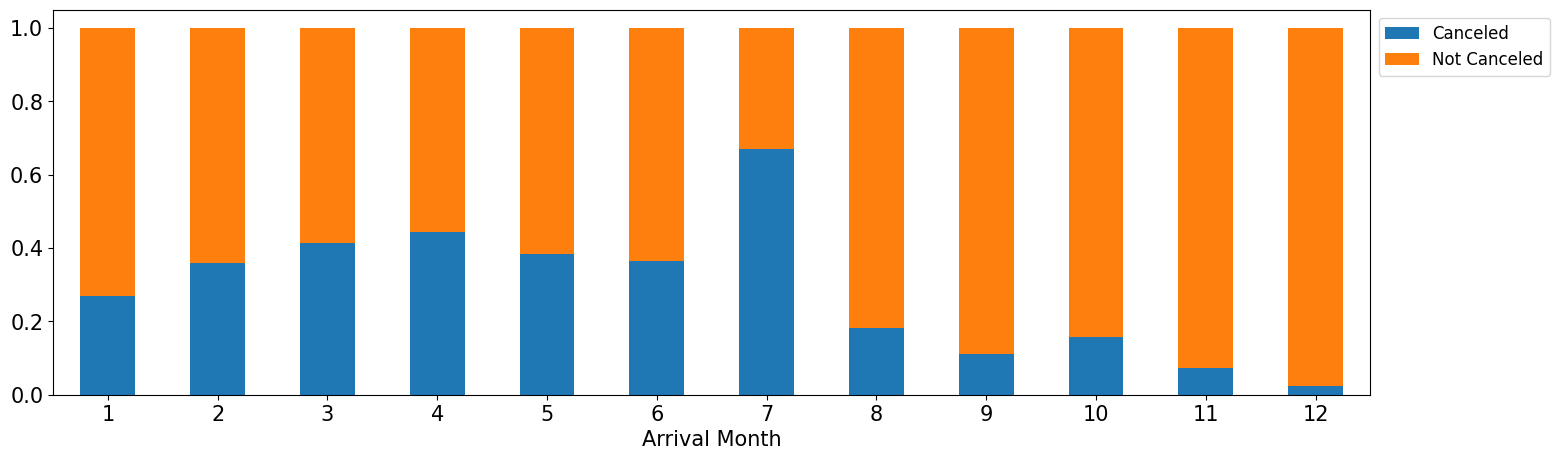

In [17]:
# visualizing the percentage of bookings canceled in each month
stacked_barplot(data, "arrival_month", "booking_status")

In [18]:
#Data Preprocessing

In [19]:
# encoding the output (also called target) attribute
data["booking_status"] = data["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)

In [20]:
# separating the input and output variables
X = data.drop(["booking_status","booking_id","arrival_date","rebooked"], axis=1)
y = data["booking_status"]

# encoding the categorical input variables
X = pd.get_dummies(X, drop_first=True)

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

# defining the AI model to build
model = RandomForestClassifier(class_weight="balanced", random_state=1)

# training the AI model on the train data
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [22]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

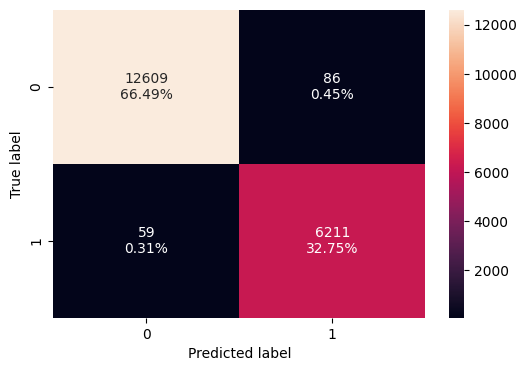

In [23]:
# confusion matrix for train data
confusion_matrix_sklearn(model, X_train, y_train)

In [24]:
# evaluating the model performance on the train data
model_train_predictions = model.predict(X_train)
model_train_score = f1_score(y_train, model_train_predictions)

print("Model Score on Train Data:", np.round(100*model_train_score, 2))

Model Score on Train Data: 98.85


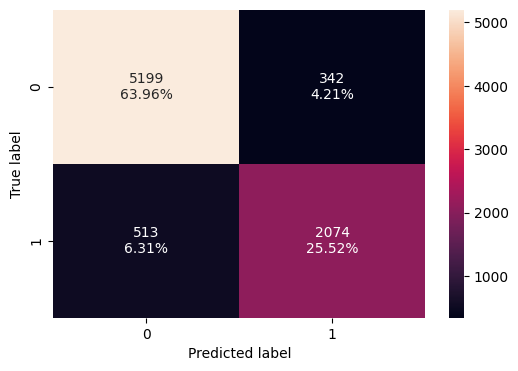

In [25]:
# confusion matrix for test data
confusion_matrix_sklearn(model, X_test, y_test)

In [26]:
# evaluating the model performance on the test data
model_test_predictions = model.predict(X_test)
model_test_score = f1_score(y_test, model_test_predictions)

print("Model Score on Test Data:", np.round(100*model_test_score, 2))

Model Score on Test Data: 82.91


In [27]:
# choosing the type of AI model
dummy_model = RandomForestClassifier(class_weight='balanced', random_state=1)

# defining the grid of parameters of the AI model to choose from
parameters = {
    'max_depth': [3,4,5,6],
    'min_samples_leaf': np.arange(5,25,5),
    'max_features': [0.6,0.7,0.8],
    'n_estimators': np.arange(50,250,50)
}

# defining the model score on which we want to compare parameter combinations
scorer = make_scorer(f1_score)

# running the model tuning algorithm
grid_obj = GridSearchCV(dummy_model, parameters, scoring=scorer, cv=5, n_jobs=-2)
grid_obj = grid_obj.fit(X_train, y_train)

In [28]:
# selecting the best combination of parameters for the model to create a new model
tuned_model = grid_obj.best_estimator_

# training the new AI model
tuned_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, max_features=0.7,
                       min_samples_leaf=5, n_estimators=50, random_state=1)

In [29]:
# evaluating the model performance on the train data
tuned_model_train_predictions = tuned_model.predict(X_train)
tuned_model_train_score = f1_score(y_train, tuned_model_train_predictions)

print("Model Score on Train Data:", np.round(100*tuned_model_train_score, 2))

Model Score on Train Data: 76.75


In [30]:
# evaluating the model performance on the test data
tuned_model_test_predictions = tuned_model.predict(X_test)
tuned_model_test_score = f1_score(y_test, tuned_model_test_predictions)

print("Model Score on Test Data:", np.round(100*tuned_model_test_score, 2))

Model Score on Test Data: 75.59


In [31]:
#Model Testing

In [32]:
final_model = tuned_model

In [33]:
# evaluating the model performance on the test data
final_model_test_predictions = final_model.predict(X_test)
final_model_test_score = f1_score(y_test, final_model_test_predictions)

print("Model Score on Test Data:", np.round(100*final_model_test_score, 2))

Model Score on Test Data: 75.59


In [ ]:
#Model Deployment

In [34]:
# exporting the final model to the disk
joblib.dump(final_model, 'hotel_cancellation_prediction_model_v1_0.joblib')

['hotel_cancellation_prediction_model_v1_0.joblib']

In [35]:
# loading the final model from the disk
cancellation_predictor = joblib.load('hotel_cancellation_prediction_model_v1_0.joblib')

In [36]:
# define a function that will take the necessary inputs and make predictions

def predict_cancellation(lead_time, market_segment_type, avg_price_per_room, no_of_adults, no_of_weekend_nights, no_of_week_nights, no_of_special_requests, arrival_month, required_car_parking_space):

    # dictionary of inputs
    input_data = {
        'lead_time': lead_time,
        'no_of_special_requests': no_of_special_requests,
        'avg_price_per_room': avg_price_per_room,
        'no_of_adults': no_of_adults,
        'no_of_weekend_nights': no_of_weekend_nights,
        'required_car_parking_space': 1.0 if required_car_parking_space == "Yes" else 0.0,
        'no_of_week_nights': no_of_week_nights,
        'arrival_month': arrival_month,
        'market_segment_type_Online': 1 if market_segment_type == 'Online' else 0,
    }

    # create a dataframe using the dictionary of inputs
    data_point = pd.DataFrame([input_data])

    # predicting the output and probability of the output
    prediction = cancellation_predictor.predict(data_point).tolist()
    prediction_prob = np.round(100*cancellation_predictor.predict_proba(data_point)[0][0], 2) if prediction == 1 else np.round(100*cancellation_predictor.predict_proba(data_point)[0][1], 2)

    # returning the final output
    return ("Yes", str(prediction_prob)+"%") if prediction[0] == 1 else ("No", str(prediction_prob)+"%")

In [37]:
# creating the deployment input interface
model_inputs = [
    gr.Number(label="Lead Time"),
    gr.Dropdown(label="Market Segment Type", choices=["Online", "Offline"]),
    gr.Number(label="Average Price per Room"),
    gr.Number(label="Number of Adults"),
    gr.Number(label="Number of Weekend Nights"),
    gr.Number(label="Number of Week Nights"),
    gr.Number(label="Number of Special Requests"),
    gr.Dropdown(label="Arrival Month", choices=np.arange(1,13,1).tolist()),
    gr.Dropdown(label="Required Car Parking Space", choices=["Yes", "No"])
]

# creating the deployment output interface
model_outputs = [
    gr.Textbox(label="Will the booking be cancelled?"),
    gr.Textbox(label="Chances of Cancellation")
]

In [41]:
# defining the structure of the deployment interface and how the components will interact
demo = gr.Interface(
    fn = predict_cancellation,
    inputs = model_inputs,
    outputs = model_outputs,
    title = "Hotel Booking Cancellation Predictor",
    description = "This interface will predict whether a given hotel booking is likely to be cancelled based on the details of the booking.",
)

In [44]:
# deploying the model
demo.launch(inline=False, share=True, debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3aaf41c55faf45fbb0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.


In [ ]:
# Predictions on New Data

In [43]:
# defining the location where the data is stored
path = "/content/INNHotelsGroup_newdata.csv"
# loading the data into a Pandas dataframe
hotel_new = pd.read_csv(path)

In [45]:
hotel_new.sample(10, random_state=42)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
1407,INNHG_129534,142,Online,1,186.30,2,0,2022-08-03,1,3,Not Canceled
411,INNHG_128538,98,Online,1,114.30,2,0,2022-07-07,0,1,Canceled
802,INNHG_128929,140,Online,0,114.33,2,1,2022-07-18,0,3,Not Canceled
3033,INNHG_131160,35,Offline,0,85.50,2,1,2022-09-17,0,1,Not Canceled
1546,INNHG_129673,192,Online,0,99.45,2,1,2022-08-04,0,3,Canceled
554,INNHG_128681,134,Online,2,89.85,2,0,2022-07-12,0,4,Not Canceled
810,INNHG_128937,29,Online,1,144.55,2,1,2022-07-18,0,3,Not Canceled
3168,INNHG_131295,76,Offline,0,102.68,2,2,2022-09-18,0,0,Canceled
1068,INNHG_129195,190,Online,1,99.95,2,2,2022-07-24,1,2,Not Canceled
270,INNHG_128397,104,Online,1,83.12,2,0,2022-07-06,0,4,Not Canceled


In [46]:
# converting the 'arrival_date' column to datetime type
hotel_new['arrival_date'] = pd.to_datetime(hotel_new['arrival_date'])

# extracting month from 'arrival_date'
hotel_new['arrival_month'] = hotel_new['arrival_date'].dt.month

# encoding the output (also called target) attribute
hotel_new["booking_status"] = hotel_new["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)

# separating the input and output variables
X_new = hotel_new.drop(["booking_status","booking_id","arrival_date"], axis=1)
y_new = hotel_new["booking_status"]

# encoding the categorical input variables
X_new = pd.get_dummies(X_new, drop_first=True)

In [47]:
# making predictions on new data
y_pred_new = cancellation_predictor.predict(X_new)

In [48]:
# checking the performance of the model on new data
model_score_new = f1_score(y_new, y_pred_new)

print("Model Score on New Data:", np.round(100*model_score_new, 2))

Model Score on New Data: 70.32


In [49]:
# adding a new column for model predictions in the data
hotel_new['model_predictions'] = y_pred_new
hotel_new.head()

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,arrival_month,model_predictions
0,INNHG_128127,4,Online,1,103.00,1,0,2022-07-01,1,1,0,7,0
1,INNHG_128128,147,Online,2,103.70,2,2,2022-07-01,0,2,0,7,0
2,INNHG_128129,43,Online,1,126.90,2,1,2022-07-01,1,2,0,7,0
3,INNHG_128130,145,Offline,0,72.76,2,0,2022-07-01,0,1,0,7,0
4,INNHG_128131,86,Offline,1,107.69,2,1,2022-07-01,0,2,0,7,0


In [55]:
# adding a new column rebooked to the new data
# we will be marking all cases where the model predicts cancellation for rebooking
hotel_new['rebooked'] = hotel_new['model_predictions'].apply(lambda x: 'Yes' if x==1 else 'No')

# ensuring 'arrival_date' in 'data' is datetime type
data['arrival_date'] = pd.to_datetime(data['arrival_date'])

# adding a new column arrival_quarter to the past and new data
data['arrival_quarter'] = data['arrival_date'].dt.year.astype(str) + '-Q' + data['arrival_date'].dt.quarter.astype(str)
hotel_new['arrival_quarter'] = hotel_new['arrival_date'].dt.year.astype(str) + '-Q' + hotel_new['arrival_date'].dt.quarter.astype(str)

In [60]:
# computing inventory loss for past quarters
past_quarter_inv_loss = 100*data[(data.booking_status == 1) & (data.rebooked == 'No')].groupby('arrival_quarter')['booking_status'].count()/data.groupby('arrival_quarter')['booking_status'].count()
past_quarter_inv_loss

,booking_status
arrival_quarter,
2021-Q1,NaN
2021-Q2,NaN
2021-Q3,NaN
2021-Q4,NaN
2022-Q1,NaN
2022-Q2,NaN


In [59]:
# computing inventory loss for new quarters
new_quarter_inv_loss = 100*hotel_new[(hotel_new.booking_status == 1) & (hotel_new.rebooked == 'No')].groupby('arrival_quarter')['booking_status'].count()/hotel_new.groupby('arrival_quarter')['booking_status'].count()
new_quarter_inv_loss

,booking_status
arrival_quarter,
2022-Q3,10.02


In [61]:
# formatting and storing the inventory loss numbers separately
inv_loss_plot_df = pd.concat([past_quarter_inv_loss.reset_index(), new_quarter_inv_loss.reset_index()])
inv_loss_plot_df.columns = ['quarter', 'inventory_loss']
inv_loss_plot_df.reset_index(inplace=True, drop=True)
inv_loss_plot_df

,quarter,inventory_loss
0,2021-Q1,NaN
1,2021-Q2,NaN
2,2021-Q3,NaN
3,2021-Q4,NaN
4,2022-Q1,NaN
5,2022-Q2,NaN
6,2022-Q3,10.02


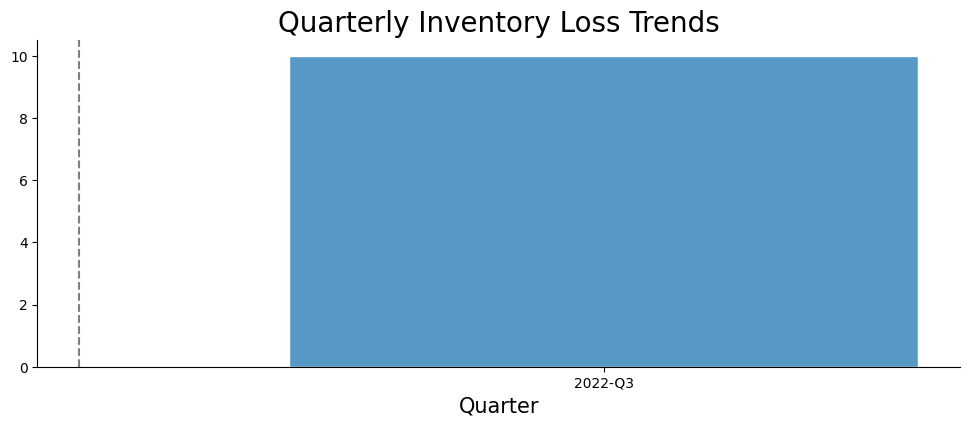

In [62]:
# plotting the revenue numbers

plt.figure(figsize=(10,4))
sns.histplot(
    inv_loss_plot_df,
    x='quarter',
    weights='inventory_loss',
    multiple='stack',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(5.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.xlabel('Quarter', fontsize=15)
plt.ylabel('')
plt.title('Quarterly Inventory Loss Trends', fontsize=20);

In [63]:
# adding a new column arrival_quarter to the past and new data
data['arrival_month'] = data['arrival_date'].apply(lambda x: str(x.year) + '-M0' + str(x.month) if x.month < 10 else str(x.year) + '-M' + str(x.month))
hotel_new['arrival_month'] = hotel_new['arrival_date'].apply(lambda x: str(x.year) + '-M0' + str(x.month) if x.month < 10 else str(x.year) + '-M' + str(x.month))

In [64]:
# computing inventory loss for past months
past_month_inv_loss = 100*data[(data.booking_status == 1) & (data.rebooked == 'No')].groupby('arrival_month')['booking_status'].count()/data.groupby('arrival_month')['booking_status'].count()
past_month_inv_loss

,booking_status
arrival_month,
2021-M01,NaN
2021-M02,NaN
2021-M03,NaN
2021-M04,NaN
2021-M05,NaN
2021-M06,NaN
2021-M07,NaN
2021-M08,NaN
2021-M09,NaN


In [65]:
# computing inventory loss for new months
new_month_inv_loss = 100*hotel_new[(hotel_new.booking_status == 1) & (hotel_new.rebooked == 'No')].groupby('arrival_month')['booking_status'].count()/hotel_new.groupby('arrival_month')['booking_status'].count()
new_month_inv_loss

,booking_status
arrival_month,
2022-M07,6.47
2022-M08,9.78
2022-M09,14.48


In [66]:
# formatting and storing the inventory loss numbers separately
inv_loss_plot_df = pd.concat([past_month_inv_loss.reset_index(), new_month_inv_loss.reset_index()])
inv_loss_plot_df.columns = ['month', 'inventory_loss']
inv_loss_plot_df.reset_index(inplace=True, drop=True)
inv_loss_plot_df

,month,inventory_loss
0,2021-M01,NaN
1,2021-M02,NaN
2,2021-M03,NaN
3,2021-M04,NaN
4,2021-M05,NaN
5,2021-M06,NaN
6,2021-M07,NaN
7,2021-M08,NaN
8,2021-M09,NaN
9,2021-M10,NaN


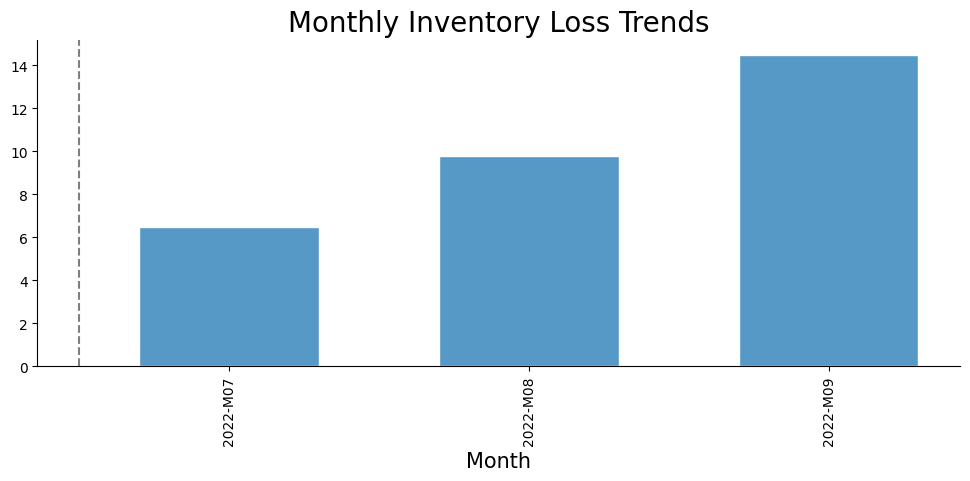

In [67]:
# plotting the revenue numbers

plt.figure(figsize=(10,4))
sns.histplot(
    inv_loss_plot_df,
    x='month',
    weights='inventory_loss',
    multiple='stack',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(17.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.xlabel('Month', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('')
plt.title('Monthly Inventory Loss Trends', fontsize=20);

In [68]:
# computing quarterly revenue for past quarters for non-canceled bookings
past_quarter_rev_non_canc = data[data.booking_status == 0].groupby('arrival_quarter')['avg_price_per_room'].sum()
past_quarter_rev_non_canc

,avg_price_per_room
arrival_quarter,


In [69]:
# computing quarterly revenue for past quarters for non-canceled bookings
new_quarter_rev_non_canc = hotel_new[hotel_new.booking_status == 0].groupby('arrival_quarter')['avg_price_per_room'].sum()
new_quarter_rev_non_canc

,avg_price_per_room
arrival_quarter,
2022-Q3,288172.44


In [70]:
# computing quarterly revenue for past quarters for rebooking of canceled bookings
past_quarter_rev_rebook = data[(data.booking_status == 1) & (data.rebooked == 'Yes')].groupby('arrival_quarter')['avg_price_per_room'].sum()
past_quarter_rev_rebook

,avg_price_per_room
arrival_quarter,


In [71]:
# computing quarterly revenue for past quarters for rebooking of canceled bookings
new_quarter_rev_rebook = hotel_new[(hotel_new.booking_status == 1) & (hotel_new.rebooked == 'Yes')].groupby('arrival_quarter')['avg_price_per_room'].sum()
new_quarter_rev_rebook

,avg_price_per_room
arrival_quarter,
2022-Q3,100305.77


In [73]:
import pandas as pd

# formatting and storing the revenue numbers separately

# Create a list to hold dataframes for concatenation
dfs_to_concat = []

# Process past_quarter_rev_non_canc
if not past_quarter_rev_non_canc.empty:
    df = past_quarter_rev_non_canc.reset_index()
    df.columns = ['quarter', 'revenue']
    df['revenue_type'] = 'Non-canceled Bookings'
    dfs_to_concat.append(df)

# Process new_quarter_rev_non_canc
if not new_quarter_rev_non_canc.empty:
    df = new_quarter_rev_non_canc.reset_index()
    df.columns = ['quarter', 'revenue']
    df['revenue_type'] = 'Non-canceled Bookings'
    dfs_to_concat.append(df)

# Process past_quarter_rev_rebook
if not past_quarter_rev_rebook.empty:
    df = past_quarter_rev_rebook.reset_index()
    df.columns = ['quarter', 'revenue']
    df['revenue_type'] = 'Rebookings'
    dfs_to_concat.append(df)

# Process new_quarter_rev_rebook
if not new_quarter_rev_rebook.empty:
    df = new_quarter_rev_rebook.reset_index()
    df.columns = ['quarter', 'revenue']
    df['revenue_type'] = 'Rebookings'
    dfs_to_concat.append(df)

# Concatenate all dataframes
if dfs_to_concat:
    rev_plot_df = pd.concat(dfs_to_concat)
    rev_plot_df.reset_index(inplace=True, drop=True)
else:
    # If all are empty, create an empty DataFrame with the expected columns
    rev_plot_df = pd.DataFrame(columns=['quarter', 'revenue', 'revenue_type'])

rev_plot_df

,quarter,revenue,revenue_type
0,2022-Q3,288172.44,Non-canceled Bookings
1,2022-Q3,100305.77,Rebookings


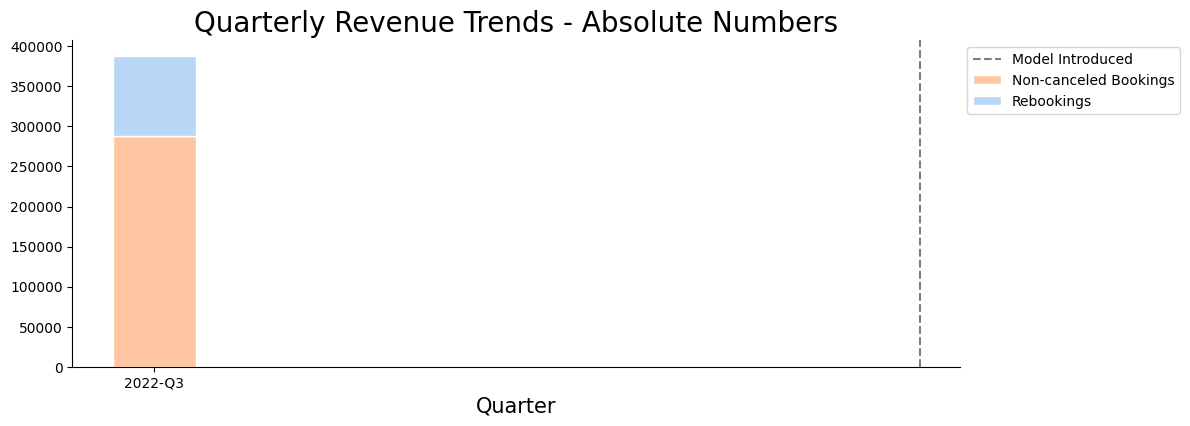

In [74]:
# plotting the revenue numbers

plt.figure(figsize=(10,4))
sns.histplot(
    rev_plot_df,
    x='quarter',
    weights='revenue',
    hue='revenue_type',
    hue_order = ['Rebookings', 'Non-canceled Bookings'],
    multiple='stack',
    palette='pastel',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(5.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.legend(['Model Introduced', 'Non-canceled Bookings', 'Rebookings'], bbox_to_anchor=(1, 1))
plt.xlabel('Quarter', fontsize=15)
plt.ylabel('')
plt.title('Quarterly Revenue Trends - Absolute Numbers', fontsize=20);

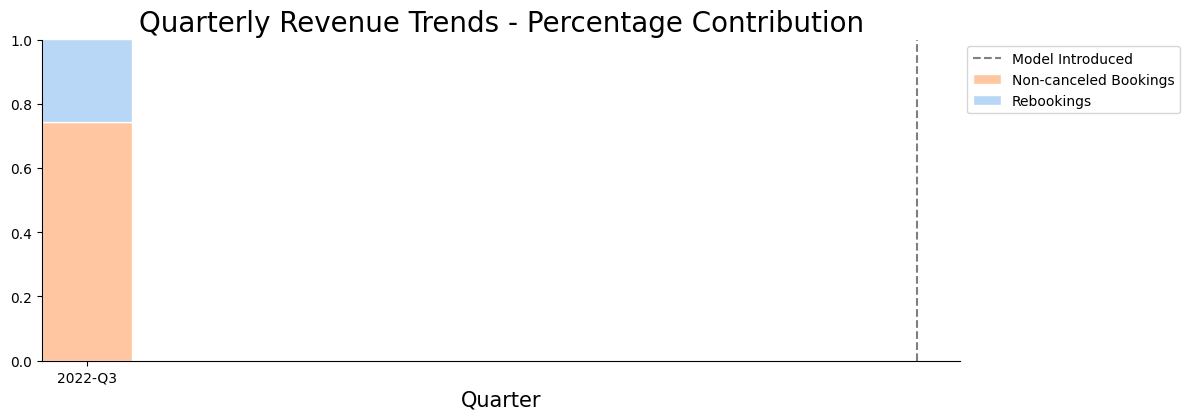

In [75]:
# plotting the revenue numbers

plt.figure(figsize=(10,4))
sns.histplot(
    rev_plot_df,
    x='quarter',
    weights='revenue',
    hue='revenue_type',
    hue_order = ['Rebookings', 'Non-canceled Bookings'],
    multiple='fill',
    palette='pastel',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(5.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.legend(['Model Introduced', 'Non-canceled Bookings', 'Rebookings'], bbox_to_anchor=(1, 1))
plt.xlabel('Quarter', fontsize=15)
plt.ylabel('')
plt.title('Quarterly Revenue Trends - Percentage Contribution', fontsize=20);

In [76]:
# computing monthly revenue for past months for non-canceled bookings
past_month_rev_non_canc = data[data.booking_status == 0].groupby('arrival_month')['avg_price_per_room'].sum()
past_month_rev_non_canc

,avg_price_per_room
arrival_month,


In [77]:
# computing monthly revenue for past months for non-canceled bookings
new_month_rev_non_canc = hotel_new[hotel_new.booking_status == 0].groupby('arrival_month')['avg_price_per_room'].sum()
new_month_rev_non_canc

,avg_price_per_room
arrival_month,
2022-M07,102183.10
2022-M08,91759.88
2022-M09,94229.46


In [78]:
# computing monthly revenue for past months for rebooking of canceled bookings
past_month_rev_rebook = data[(data.booking_status == 1) & (data.rebooked == 'Yes')].groupby('arrival_month')['avg_price_per_room'].sum()
past_month_rev_rebook

,avg_price_per_room
arrival_month,


In [79]:
# computing monthly revenue for past months for rebooking of canceled bookings
new_month_rev_rebook = hotel_new[(hotel_new.booking_status == 1) & (hotel_new.rebooked == 'Yes')].groupby('arrival_month')['avg_price_per_room'].sum()
new_month_rev_rebook

,avg_price_per_room
arrival_month,
2022-M07,41358.86
2022-M08,32353.08
2022-M09,26593.83


In [81]:
import pandas as pd

# formatting and storing the revenue numbers separately

# Create a list to hold dataframes for concatenation
dfs_to_concat = []

# Process past_month_rev_non_canc
if not past_month_rev_non_canc.empty:
    df = past_month_rev_non_canc.reset_index()
    df.columns = ['month', 'revenue']
    df['revenue_type'] = 'Non-canceled Bookings'
    dfs_to_concat.append(df)

# Process new_month_rev_non_canc
if not new_month_rev_non_canc.empty:
    df = new_month_rev_non_canc.reset_index()
    df.columns = ['month', 'revenue']
    df['revenue_type'] = 'Non-canceled Bookings'
    dfs_to_concat.append(df)

# Process past_month_rev_rebook
if not past_month_rev_rebook.empty:
    df = past_month_rev_rebook.reset_index()
    df.columns = ['month', 'revenue']
    df['revenue_type'] = 'Rebookings'
    dfs_to_concat.append(df)

# Process new_month_rev_rebook
if not new_month_rev_rebook.empty:
    df = new_month_rev_rebook.reset_index()
    df.columns = ['month', 'revenue']
    df['revenue_type'] = 'Rebookings'
    dfs_to_concat.append(df)

# Concatenate all dataframes
if dfs_to_concat:
    rev_plot_df = pd.concat(dfs_to_concat)
    rev_plot_df.reset_index(inplace=True, drop=True)
else:
    # If all are empty, create an empty DataFrame with the expected columns
    rev_plot_df = pd.DataFrame(columns=['month', 'revenue', 'revenue_type'])

rev_plot_df

,month,revenue,revenue_type
0,2022-M07,102183.10,Non-canceled Bookings
1,2022-M08,91759.88,Non-canceled Bookings
2,2022-M09,94229.46,Non-canceled Bookings
3,2022-M07,41358.86,Rebookings
4,2022-M08,32353.08,Rebookings
5,2022-M09,26593.83,Rebookings


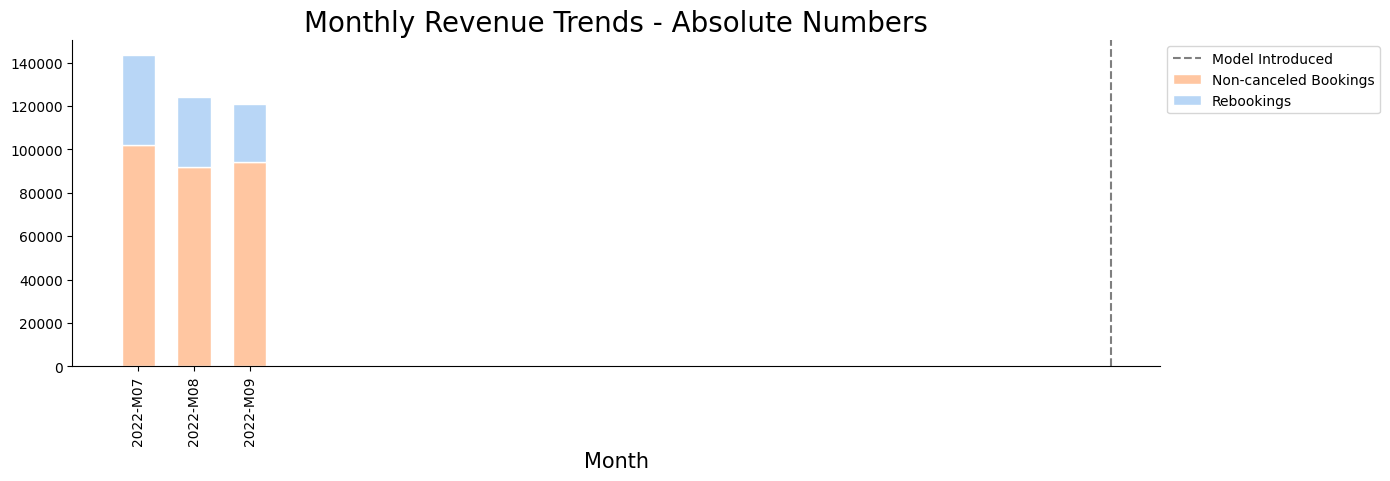

In [82]:
# plotting the revenue numbers

plt.figure(figsize=(12,4))
sns.histplot(
    rev_plot_df,
    x='month',
    weights='revenue',
    hue='revenue_type',
    hue_order = ['Rebookings', 'Non-canceled Bookings'],
    multiple='stack',
    palette='pastel',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(17.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.legend(['Model Introduced', 'Non-canceled Bookings', 'Rebookings'], bbox_to_anchor=(1, 1))
plt.xlabel('Month', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('')
plt.title('Monthly Revenue Trends - Absolute Numbers', fontsize=20);

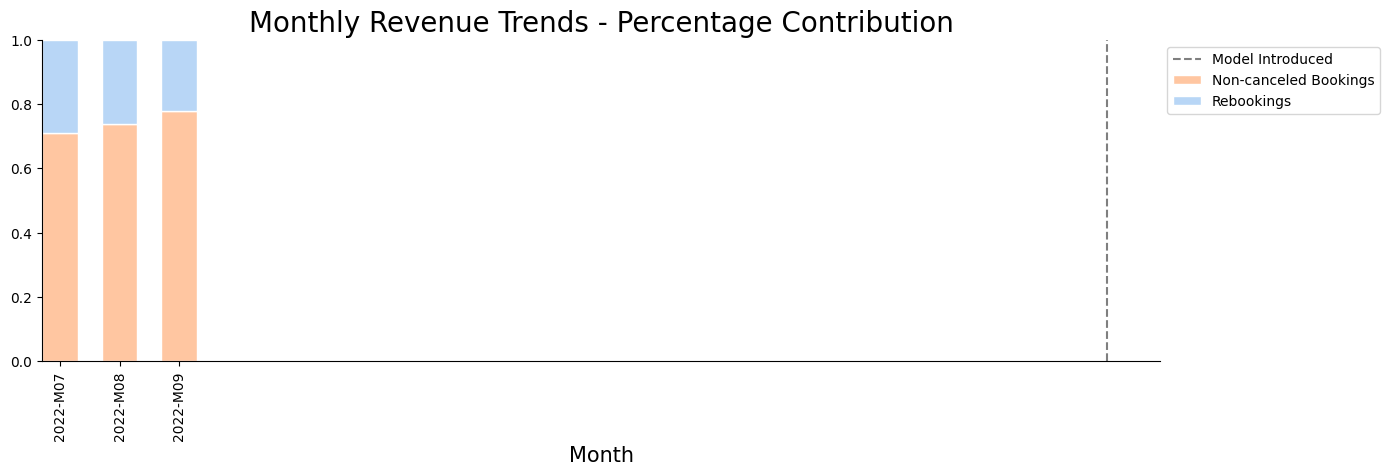

In [83]:
# plotting the revenue numbers

plt.figure(figsize=(12,4))
sns.histplot(
    rev_plot_df,
    x='month',
    weights='revenue',
    hue='revenue_type',
    hue_order = ['Rebookings', 'Non-canceled Bookings'],
    multiple='fill',
    palette='pastel',
    edgecolor='white',
    shrink=0.6
)

# adding a vertical line to mark the point from where the model was introduced
plt.axvline(17.5, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.legend(['Model Introduced', 'Non-canceled Bookings', 'Rebookings'], bbox_to_anchor=(1, 1))
plt.xlabel('Month', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('')
plt.title('Monthly Revenue Trends - Percentage Contribution', fontsize=20);

In [84]:
# formatting and storing the model score separately
model_perf_df = pd.DataFrame(hotel_new.arrival_month.unique(), columns=['month'])
model_perf_df['model_score'] = np.nan

# computing and storing the model score at month level
for mon in hotel_new.arrival_month.unique():
    df_aux = hotel_new[hotel_new.arrival_month == mon]
    model_score = f1_score(df_aux['booking_status'].values, df_aux['model_predictions'].values)
    model_perf_df.loc[model_perf_df.month == mon, 'model_score'] = model_score

model_perf_df

,month,model_score
0,2022-M07,0.72
1,2022-M08,0.70
2,2022-M09,0.67


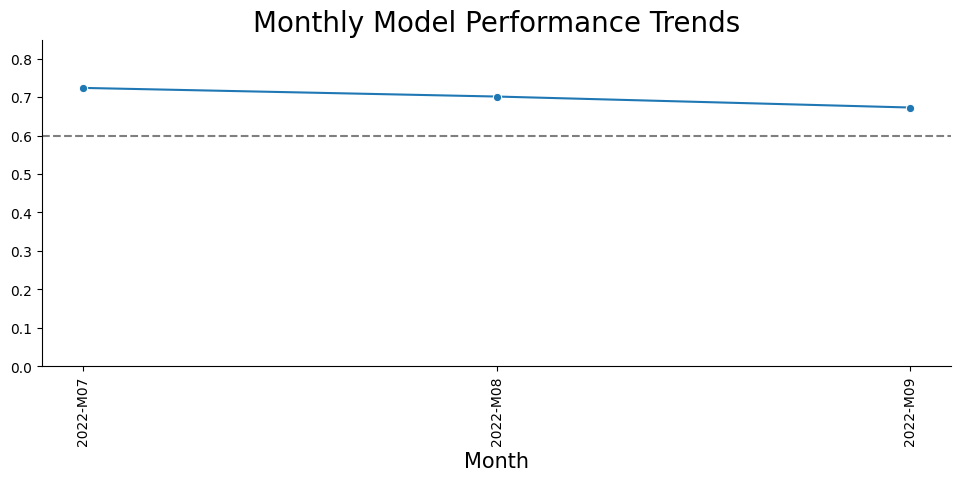

In [85]:
# plotting the model score

plt.figure(figsize=(10,4))
sns.lineplot(
    model_perf_df.iloc[:15, :],
    x='month',
    y='model_score',
    marker='o',
)

# adding a horizontal line to mark the lower limit of acceptable model score
plt.axhline(0.6, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.xlabel('Month', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('')
plt.ylim(0, 0.85)
plt.title('Monthly Model Performance Trends', fontsize=20);

In [86]:
# adding a new column arrival_week
hotel_new['arrival_week'] = hotel_new['arrival_date'].dt.year.astype(str) + '-W' + hotel_new['arrival_date'].dt.isocalendar().week.astype(str)
hotel_new.head()

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,arrival_month,model_predictions,rebooked,arrival_quarter,arrival_week
0,INNHG_128127,4,Online,1,103.00,1,0,2022-07-01,1,1,0,2022-M07,0,No,2022-Q3,2022-W26
1,INNHG_128128,147,Online,2,103.70,2,2,2022-07-01,0,2,0,2022-M07,0,No,2022-Q3,2022-W26
2,INNHG_128129,43,Online,1,126.90,2,1,2022-07-01,1,2,0,2022-M07,0,No,2022-Q3,2022-W26
3,INNHG_128130,145,Offline,0,72.76,2,0,2022-07-01,0,1,0,2022-M07,0,No,2022-Q3,2022-W26
4,INNHG_128131,86,Offline,1,107.69,2,1,2022-07-01,0,2,0,2022-M07,0,No,2022-Q3,2022-W26


In [87]:
# formatting and storing the model score separately
model_perf_df = pd.DataFrame(hotel_new.arrival_week.unique(), columns=['week'])
model_perf_df['model_score'] = np.nan

# computing and storing the model score at week level
for wk in hotel_new.arrival_week.unique():
    df_aux = hotel_new[hotel_new.arrival_week == wk]
    model_score = f1_score(df_aux['booking_status'].values, df_aux['model_predictions'].values)
    model_perf_df.loc[model_perf_df.week == wk, 'model_score'] = model_score

model_perf_df

,week,model_score
0,2022-W26,0.72
1,2022-W27,0.76
2,2022-W28,0.65
3,2022-W29,0.72
4,2022-W30,0.75
5,2022-W31,0.73
6,2022-W32,0.74
7,2022-W33,0.55
8,2022-W34,0.68
9,2022-W35,0.62


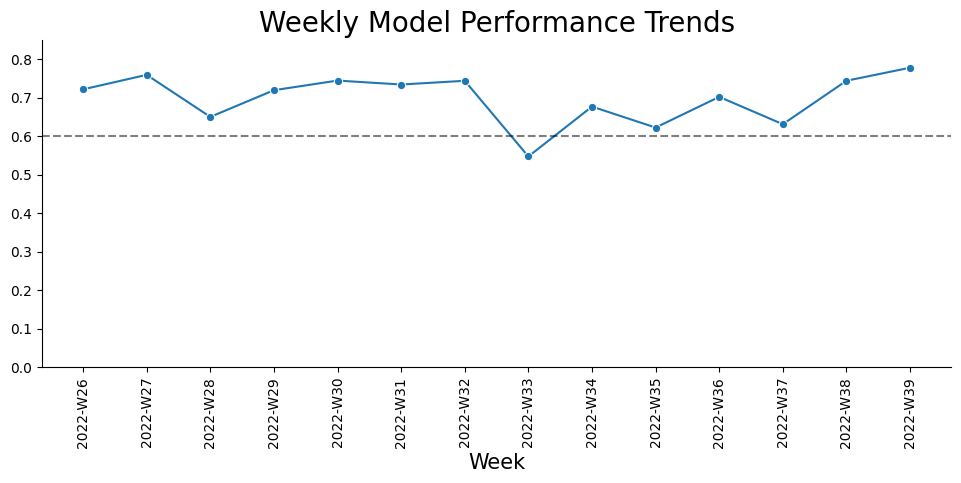

In [88]:
# plotting the model score

plt.figure(figsize=(10,4))
sns.lineplot(
    model_perf_df.iloc[:15, :],
    x='week',
    y='model_score',
    marker='o',
)

# adding a horizontal line to mark the lower limit of acceptable model score
plt.axhline(0.6, color='black', linestyle='--', alpha=0.5)

# plot formatting
sns.despine()
plt.tight_layout()
plt.xlabel('Week', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('')
plt.ylim(0, 0.85)
plt.title('Weekly Model Performance Trends', fontsize=20);